In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

np.random.seed(42)

S0    = 669.03   
mu    = 0.042    
T     = 1.0      
N     = 252      
M     = 1000     

sigma_const = 0.20   

v0    = 0.04    
kappa = 2.0      
theta = 0.04     
xi    = 0.3      
rho   = -0.7     

# Parámetros Merton
lam   = 4.0     
mu_j  = -0.05   
sig_j = 0.07     

print("Parametros cargados correctamente.")
print("Simulaciones: " + str(M) + " | Pasos: " + str(N) + " | Horizonte: " + str(T) + " año(s)")


Parametros cargados correctamente.
Simulaciones: 1000 | Pasos: 252 | Horizonte: 1.0 año(s)


In [ ]:
#  Función GBM estándar (Black-Scholes)
def simular_gbm(S0, mu, sigma, T, N, M, seed=42):
    np.random.seed(seed)
    dt = T / N
    Z  = np.random.randn(M, N)
    S  = np.zeros((M, N + 1))
    S[:, 0] = S0
    for t in range(1, N + 1):
        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z[:, t-1]
        )
    return S


#  Función Heston (volatilidad estocástica)
def simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M, seed=42):
    np.random.seed(seed)
    dt = T / N
    S  = np.zeros((M, N + 1))
    v  = np.zeros((M, N + 1))
    S[:, 0] = S0
    v[:, 0] = v0

    for t in range(1, N + 1):
        Z1 = np.random.randn(M)
        Z2 = np.random.randn(M)
        Zs = Z1
        Zv = rho * Z1 + np.sqrt(1 - rho**2) * Z2

        v_pos  = np.maximum(v[:, t-1], 0)
        v[:, t] = (v_pos
                   + kappa * (theta - v_pos) * dt
                   + xi * np.sqrt(v_pos * dt) * Zv)
        v[:, t] = np.maximum(v[:, t], 0)

        S[:, t] = S[:, t-1] * np.exp(
            (mu - 0.5 * v_pos) * dt + np.sqrt(v_pos * dt) * Zs
        )
    return S, v


#  Función Merton (saltos de precio)
def simular_merton(S0, mu, sigma, lam, mu_j, sig_j, T, N, M, seed=42):
    np.random.seed(seed)
    dt = T / N
    # corrección de drift para que sea martingala bajo Q
    kappa_j = np.exp(mu_j + 0.5 * sig_j**2) - 1
    mu_adj  = mu - lam * kappa_j

    S = np.zeros((M, N + 1))
    S[:, 0] = S0

    for t in range(1, N + 1):
        Z     = np.random.randn(M)
        # número de saltos en este paso
        n_saltos = np.random.poisson(lam * dt, M)
        # magnitud de los saltos (suma de logaritmos normales)
        log_J = np.array([
            np.sum(np.random.normal(mu_j, sig_j, n)) if n > 0 else 0.0
            for n in n_saltos
        ])
        S[:, t] = S[:, t-1] * np.exp(
            (mu_adj - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z
            + log_J
        )
    return S


print("Funciones de simulacion definidas: GBM, Heston, Merton.")


Funciones de simulacion definidas: GBM, Heston, Merton.


In [ ]:
#  trayectorias + distribución
def graficar_comparacion(S_gbm, S_alt, v_alt=None,
                          titulo_alt="Modelo alternativo",
                          titulo_graf="Comparación GBM vs Modelo alternativo",
                          color_alt="steelblue"):
    n_plots = 3 if v_alt is not None else 2
    fig, axes = plt.subplots(1, n_plots, figsize=(5 * n_plots, 5))

    # Trayectorias del modelo alternativo
    for i in range(min(50, len(S_alt))):
        axes[0].plot(S_alt[i], alpha=0.3, linewidth=0.7, color=color_alt)
    axes[0].set_title("Trayectorias — " + titulo_alt)
    axes[0].set_xlabel("Días")
    axes[0].set_ylabel("Precio")
    axes[0].grid(True, alpha=0.3)

    # Distribución final
    axes[1].hist(S_gbm[:, -1], bins=60, density=True,
                 alpha=0.6, color="tomato", label="GBM (sigma constante)")
    axes[1].hist(S_alt[:, -1], bins=60, density=True,
                 alpha=0.6, color=color_alt, label=titulo_alt)
    axes[1].set_title("Distribución del precio final")
    axes[1].set_xlabel("S(T)")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Volatilidad (solo Heston tiene trayectoria de vol)
    if v_alt is not None:
        theta_val = np.mean(v_alt[:, -1])  
        for i in range(min(50, len(v_alt))):
            axes[2].plot(np.sqrt(v_alt[i]) * 100, alpha=0.3,
                         linewidth=0.7, color="darkorange")
        axes[2].set_title("Volatilidad estocástica (%)")
        axes[2].set_xlabel("Días")
        axes[2].set_ylabel("Volatilidad (%)")
        axes[2].grid(True, alpha=0.3)

    plt.suptitle(titulo_graf, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("Helper de graficas listo.")


Helper de graficas listo.


## Parte 1: Simulación base — Modelo de Heston

El modelo de Heston permite que la **volatilidad cambie con el tiempo** en lugar de ser fija.  
Esto genera distribuciones con colas más anchas: el precio puede terminar en valores más extremos de lo que Black-Scholes sugeriría.


GBM — precio final promedio  : 697.46
Heston — precio final promedio: 694.75
GBM — desviacion estandar    : 137.84
Heston — desviacion estandar : 131.27


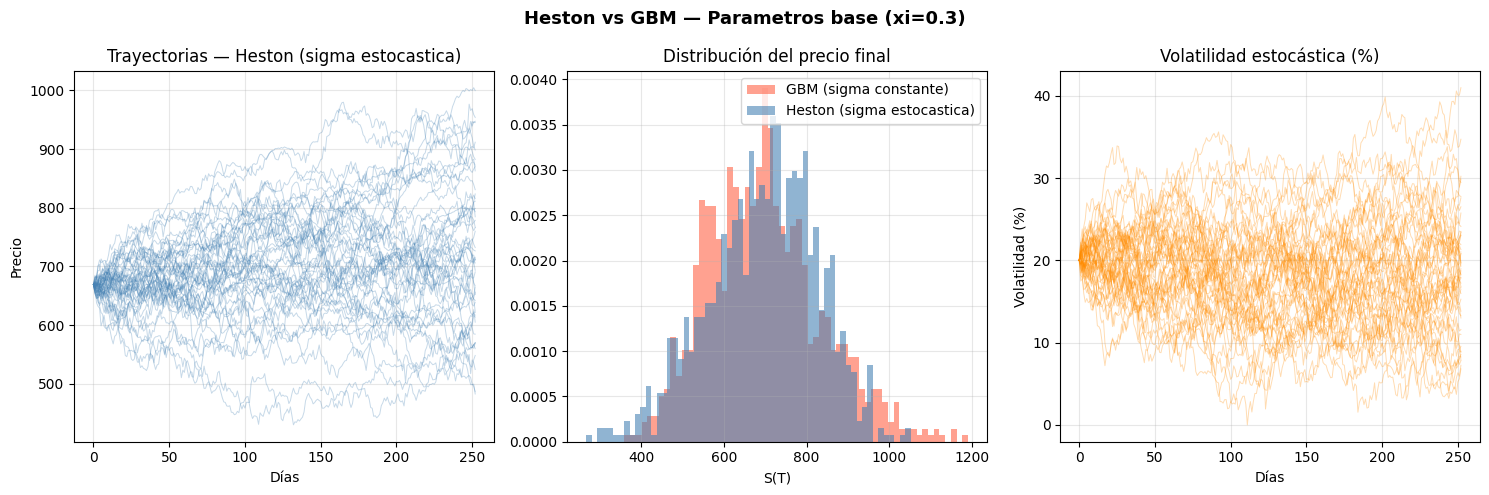

In [ ]:
S_gbm          = simular_gbm(S0, mu, sigma_const, T, N, M)
S_heston, v_h  = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)

print("GBM — precio final promedio  : " + str(round(float(np.mean(S_gbm[:, -1])), 2)))
print("Heston — precio final promedio: " + str(round(float(np.mean(S_heston[:, -1])), 2)))
print("GBM — desviacion estandar    : " + str(round(float(np.std(S_gbm[:, -1])), 2)))
print("Heston — desviacion estandar : " + str(round(float(np.std(S_heston[:, -1])), 2)))

graficar_comparacion(
    S_gbm, S_heston, v_alt=v_h,
    titulo_alt="Heston (sigma estocastica)",
    titulo_graf="Heston vs GBM — Parametros base (xi=0.3)",
    color_alt="steelblue"
)


## Parte 2: Efecto de ξ (xi) en el modelo de Heston

**ξ xi** controla cuánto varía la volatilidad.  
- Un **xi bajo** → la volatilidad apenas oscila, el resultado se parece más a GBM  
- Un **xi alto** → la volatilidad tiene picos y valles pronunciados, generando colas mucho más gruesas


xi = 0.1
  Precio final promedio : 696.12
  Desviacion estandar   : 137.27


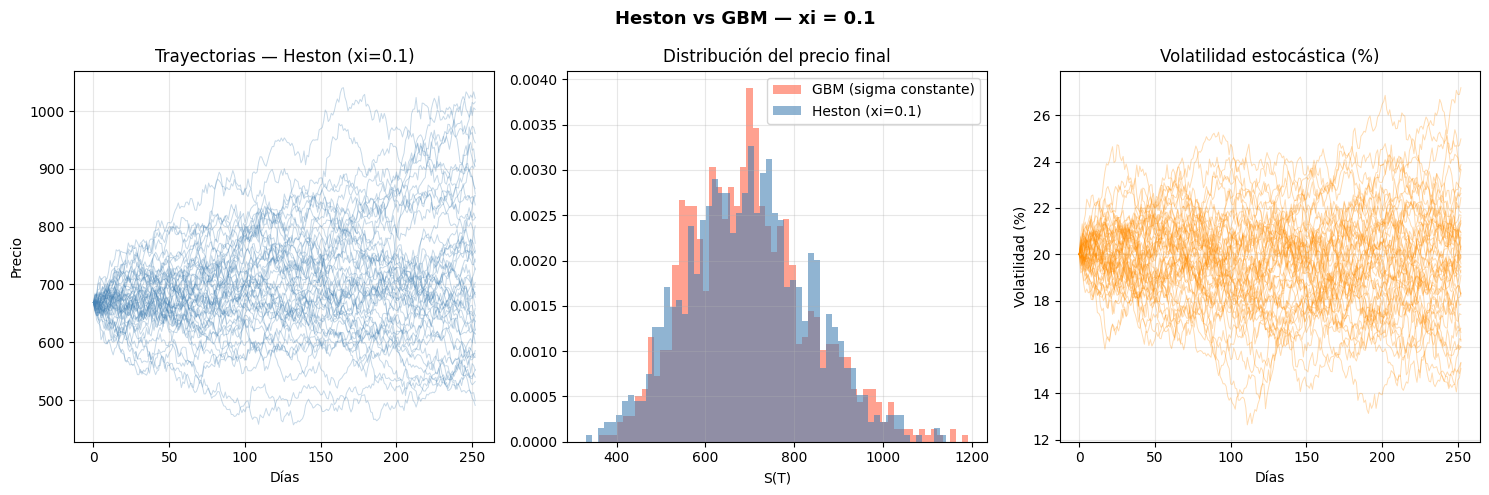

xi = 0.4
  Precio final promedio : 694.21
  Desviacion estandar   : 128.64


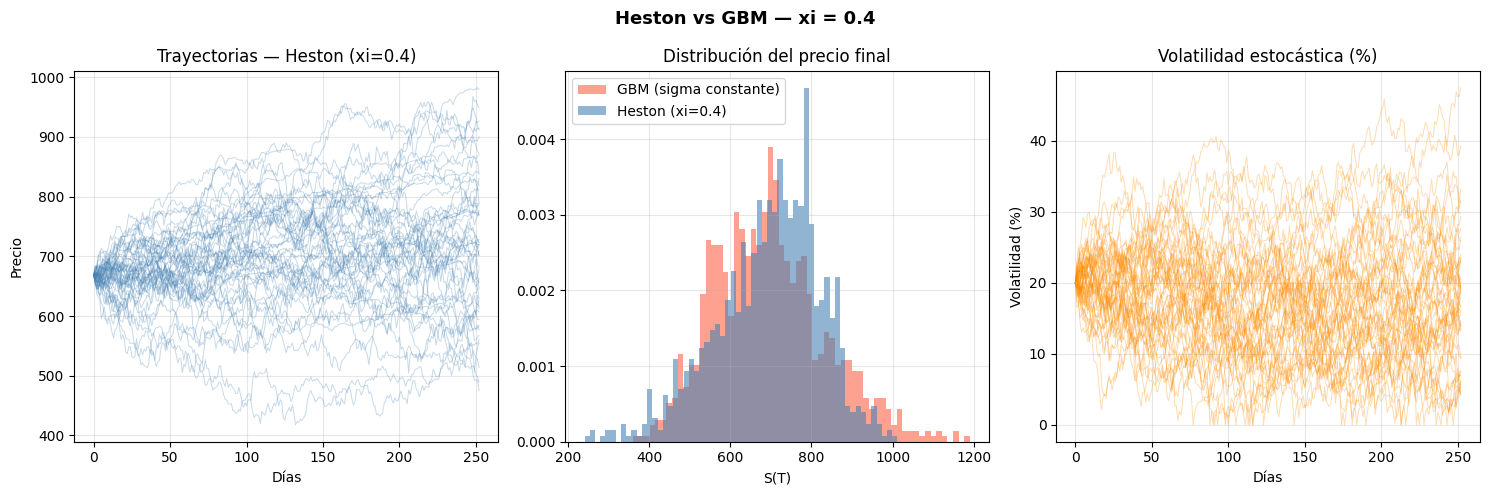

xi = 0.9
  Precio final promedio : 693.69
  Desviacion estandar   : 126.81


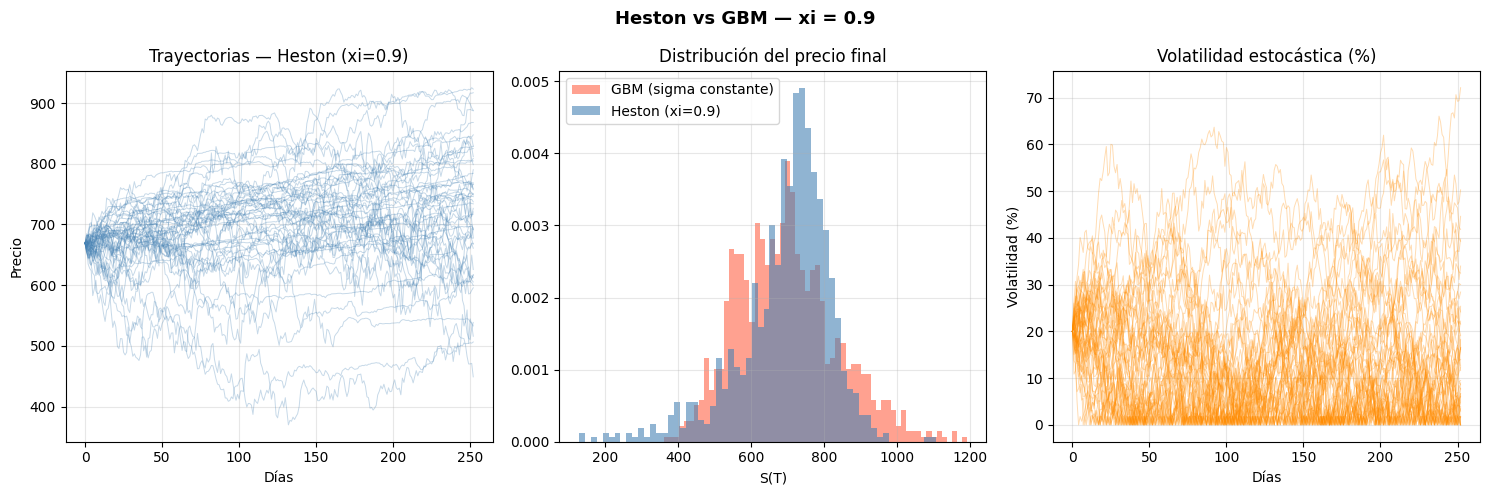

In [5]:
S_gbm = simular_gbm(S0, mu, sigma_const, T, N, M)

for xi_val in [0.1, 0.4, 0.9]:
    S_h, v_h = simular_heston(S0, v0, mu, kappa, theta, xi_val, rho, T, N, M, seed=42)

    print("xi = " + str(xi_val))
    print("  Precio final promedio : " + str(round(float(np.mean(S_h[:, -1])), 2)))
    print("  Desviacion estandar   : " + str(round(float(np.std(S_h[:, -1])), 2)))

    graficar_comparacion(
        S_gbm, S_h, v_alt=v_h,
        titulo_alt="Heston (xi=" + str(xi_val) + ")",
        titulo_graf="Heston vs GBM — xi = " + str(xi_val),
        color_alt="steelblue"
    )


## Parte 3: Simulación base — Modelo de Merton (saltos)

El modelo de Merton agrega **saltos bruscos** al proceso de precios.  
Estos saltos representan noticias inesperadas, crisis o eventos extremos.  
El resultado son distribuciones con **colas izquierdas más gruesas**: mayor probabilidad de caídas abruptas.


GBM — precio final promedio   : 697.46
Merton — precio final promedio: 704.14
GBM — desviacion estandar     : 137.84
Merton — desviacion estandar  : 186.36


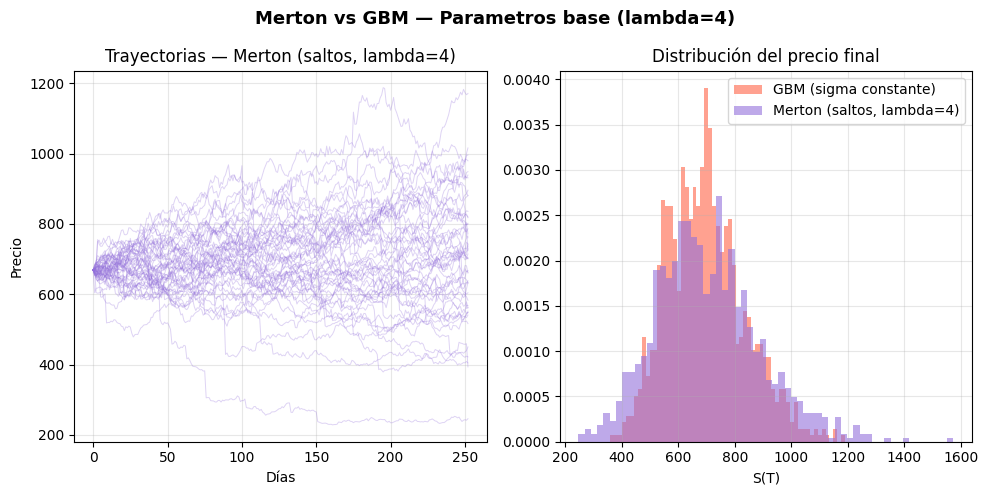

In [6]:
S_gbm    = simular_gbm(S0, mu, sigma_const, T, N, M)
S_merton = simular_merton(S0, mu, sigma_const, lam, mu_j, sig_j, T, N, M)

print("GBM — precio final promedio   : " + str(round(float(np.mean(S_gbm[:, -1])), 2)))
print("Merton — precio final promedio: " + str(round(float(np.mean(S_merton[:, -1])), 2)))
print("GBM — desviacion estandar     : " + str(round(float(np.std(S_gbm[:, -1])), 2)))
print("Merton — desviacion estandar  : " + str(round(float(np.std(S_merton[:, -1])), 2)))

graficar_comparacion(
    S_gbm, S_merton,
    titulo_alt="Merton (saltos, lambda=4)",
    titulo_graf="Merton vs GBM — Parametros base (lambda=4)",
    color_alt="mediumpurple"
)


## Parte 4: Efecto de λ (lambda) en el modelo de Merton

**λ (lambda)** es la frecuencia de saltos por año.  
- **λ = 1** → un salto al año en promedio, eventos raros  
- **λ = 4** → un salto cada trimestre  
- **λ = 15** → saltos frecuentes: la distribución se deforma significativamente


lambda = 1
  Precio final promedio : 700.01
  Desviacion estandar   : 152.43


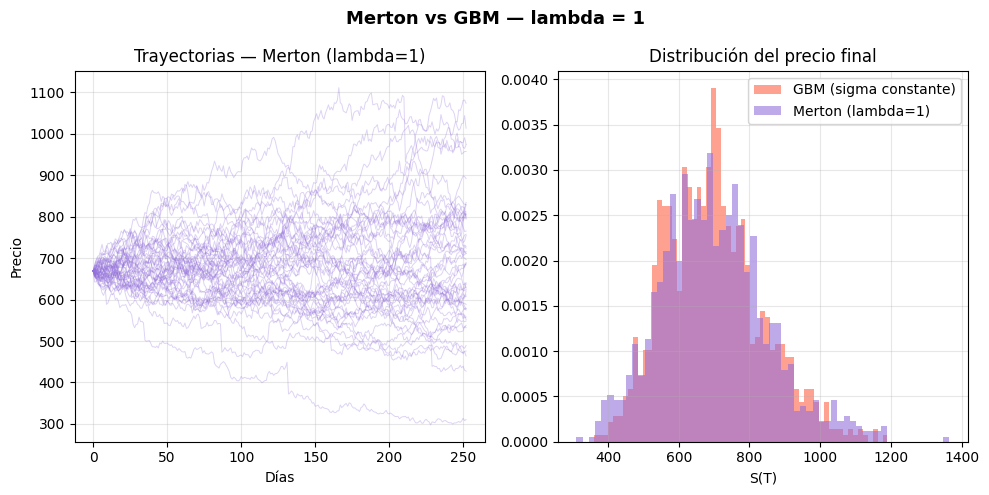

lambda = 4
  Precio final promedio : 704.14
  Desviacion estandar   : 186.36


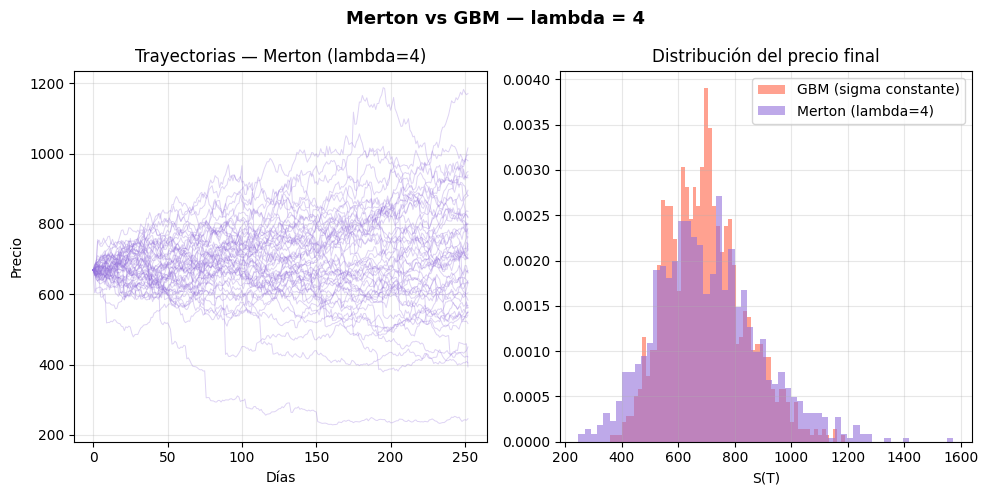

lambda = 15
  Precio final promedio : 697.66
  Desviacion estandar   : 280.75


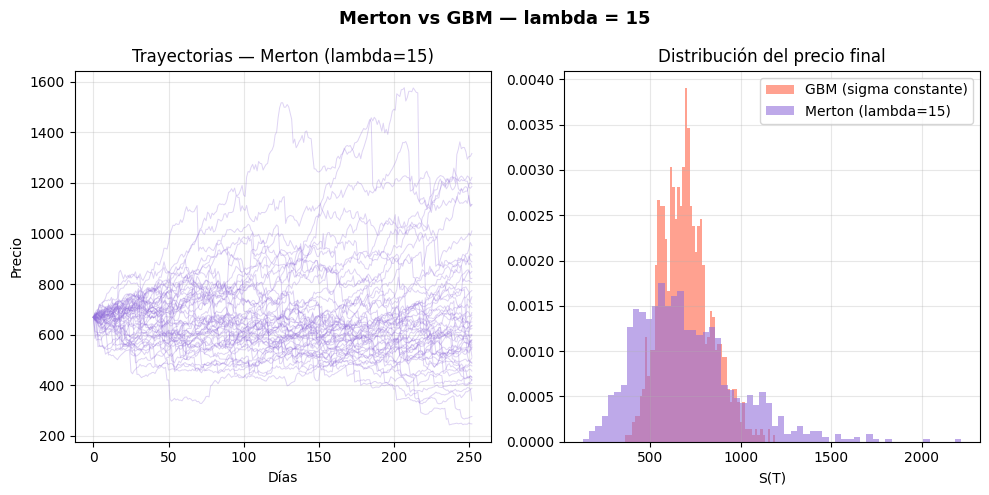

In [7]:
S_gbm = simular_gbm(S0, mu, sigma_const, T, N, M)

for lam_val in [1, 4, 15]:
    S_m = simular_merton(S0, mu, sigma_const, lam_val, mu_j, sig_j, T, N, M, seed=42)

    print("lambda = " + str(lam_val))
    print("  Precio final promedio : " + str(round(float(np.mean(S_m[:, -1])), 2)))
    print("  Desviacion estandar   : " + str(round(float(np.std(S_m[:, -1])), 2)))

    graficar_comparacion(
        S_gbm, S_m,
        titulo_alt="Merton (lambda=" + str(lam_val) + ")",
        titulo_graf="Merton vs GBM — lambda = " + str(lam_val),
        color_alt="mediumpurple"
    )


## Parte 5: Implicaciones para el precio de opciones

Con las distribuciones simuladas podemos estimar el precio de una **call europea**  
usando el método de Monte Carlo: promediamos los pagos descontados al presente.  

Esto nos permite ver cómo cada modelo valúa la opción de forma diferente al GBM.


Precio Call Europea (Strike = 700.0)
  GBM    : $51.09
  Heston : $47.96
  Merton : $72.33


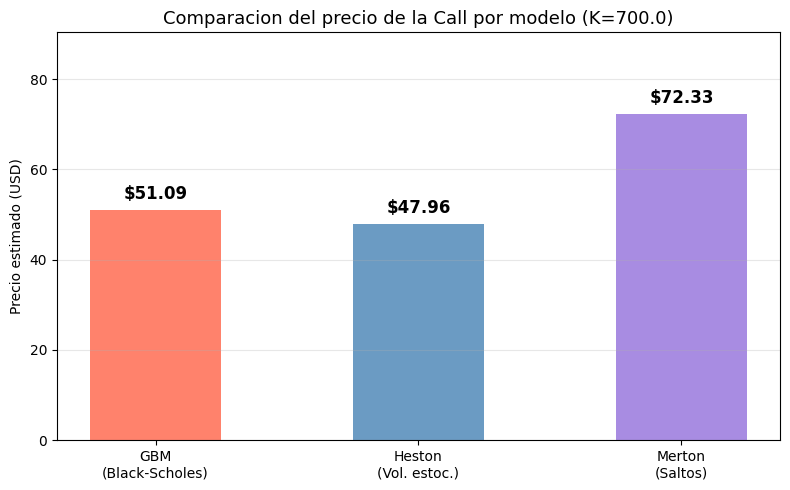


Diferencia Heston vs GBM : $-3.13
Diferencia Merton vs GBM : $21.24


In [8]:
K = 700.0    # strike de la opción
r = 0.042    # tasa libre de riesgo (misma que mu para simplificar)

def precio_call_mc(S_final, K, r, T):
    payoffs = np.maximum(S_final - K, 0)
    return np.exp(-r * T) * np.mean(payoffs)

# Simular los tres modelos
S_gbm          = simular_gbm(S0, mu, sigma_const, T, N, M)
S_heston, _    = simular_heston(S0, v0, mu, kappa, theta, xi, rho, T, N, M)
S_merton       = simular_merton(S0, mu, sigma_const, lam, mu_j, sig_j, T, N, M)

precio_gbm    = precio_call_mc(S_gbm[:, -1], K, r, T)
precio_heston = precio_call_mc(S_heston[:, -1], K, r, T)
precio_merton = precio_call_mc(S_merton[:, -1], K, r, T)

print("Precio Call Europea (Strike = " + str(K) + ")")
print("  GBM    : $" + str(round(precio_gbm, 2)))
print("  Heston : $" + str(round(precio_heston, 2)))
print("  Merton : $" + str(round(precio_merton, 2)))

# Visualización comparativa
modelos = ["GBM\n(Black-Scholes)", "Heston\n(Vol. estoc.)", "Merton\n(Saltos)"]
precios = [precio_gbm, precio_heston, precio_merton]
colores = ["tomato", "steelblue", "mediumpurple"]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(modelos, precios, color=colores, alpha=0.8, width=0.5)
ax.bar_label(bars, labels=["$" + str(round(p, 2)) for p in precios],
             padding=5, fontsize=12, fontweight="bold")
ax.set_ylabel("Precio estimado (USD)")
ax.set_title("Comparacion del precio de la Call por modelo (K=" + str(K) + ")", fontsize=13)
ax.set_ylim(0, max(precios) * 1.25)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("")
print("Diferencia Heston vs GBM : $" + str(round(precio_heston - precio_gbm, 2)))
print("Diferencia Merton vs GBM : $" + str(round(precio_merton - precio_gbm, 2)))


1. **Efecto de aumentar ξ en Heston**

Al subir ξ, la volatilidad oscila más agresivamente, lo que engrosa las colas de la distribución del precio final en ambos lados. Sobre el skew: como ρ es negativo (−0.7 en la simulación), cuando el precio cae la vol sube, lo que empuja más masa hacia la cola izquierda. Más ξ amplifica ese efecto, produciendo un skew negativo más pronunciado.

2. **Cambiar λ de 4 a 10 en Merton**
Las trayectorias muestran más quiebres bruscos y frecuentes, ya no parecen "suaves" como el GBM. En la distribución final, la cola izquierda se engrosa notablemente porque hay más eventos de caída. La media baja un poco y la distribución pierde la simetría log-normal, acercándose más a lo que se observa en mercados reales.

3. **¿BS sobreestima o subestima un put muy OTM?**
Lo subestima. Un put muy OTM solo vale algo si el precio colapsa hacia esa zona, es decir, si ocurre un evento de cola izquierda. BS asume que esa probabilidad es casi cero (distribución normal delgada), pero la realidad tiene fat tails. El mercado real le asigna más probabilidad a ese escenario, por lo que el precio "justo" es mayor al que calcula BS.

4. **Limitación de λ constante en Merton**
En la práctica la frecuencia de saltos no es estable: durante una crisis los saltos se agrupan (volatility clustering), y en periodos tranquilos casi no ocurren. Un λ fijo no captura esa dinámica. Además, el mercado no te avisa cuándo cambia de régimen, así que calibrar un λ único con datos históricos te da un promedio que no sirve bien ni para entornos tranquilos ni para crisis.

5. **¿Por qué BS sigue siendo el estándar?**
Principalmente por conveniencia operativa. BS tiene fórmula cerrada, es rápido de calcular e invertir (implied vol), y toda la industria ya habla en términos de "volatilidad implícita BS". Heston y Merton requieren calibración numérica costosa y sus parámetros son menos estables. BS se usa como lenguaje común de cotización, no porque nadie crea que es correcto, sino porque el mercado ha coordinado en torno a él. La sonrisa de volatilidad es precisamente la forma en que los traders parchen sus limitaciones sin abandonarlo.

## Conclusiones

| Modelo | Supuesto clave | Efecto en distribución | Precio de opción |
|--------|---------------|----------------------|-----------------|
| **GBM (Black-Scholes)** | Volatilidad constante | Lognormal simétrica | Referencia |
| **Heston** | Volatilidad varía con el tiempo | Colas más anchas, asimetría izquierda | Generalmente mayor |
| **Merton** | Saltos abruptos posibles | Cola izquierda muy pronunciada | Puede ser mayor o menor según λ |

**Sobre el parámetro ξ (Heston):**
- Un xi alto genera distribuciones muy dispersas con colas gruesas en ambos lados.
- Implica **mayor incertidumbre** y generalmente opciones más caras.

**Sobre el parámetro λ (Merton):**
- Pocos saltos (λ=1): el efecto es casi invisible en la distribución final.
- Muchos saltos (λ=15): la distribución se deforma notablemente hacia la izquierda, capturando riesgo de caídas abruptas.

**Conclusión general:** GBM subestima el riesgo de eventos extremos. Heston y Merton —cada uno a su manera— producen distribuciones con colas más realistas, lo que afecta directamente el precio justo de opciones, especialmente las *out-of-the-money*.
